In [ ]:
# Imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
import time
import warnings

# suppressing warnings for cleaner output
warnings.filterwarnings('ignore')

# scikit-learn stuffxa
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# plotting configs
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

# cloning the repo (make sure git is installed)
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject


Cloning into 'PRMLProject'...
remote: Enumerating objects: 280, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 280 (delta 14), reused 11 (delta 5), pack-reused 239 (from 1)
Receiving objects: 100% (280/280), 216.59 MiB | 12.08 MiB/s, done.
Resolving deltas: 100% (107/107), done.
Updating files: 100% (74/74), done.
Filtering content: 100% (16/16), 1.40 GiB | 48.68 MiB/s, done.
/content/PRMLProject


In [ ]:
# function to load pickled data
def unpickle(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)

# loading HoG + PCA processed features
X_train = unpickle("PreProcessedData/TrainFeaturesPCA_HoG.pkl")
y_train = unpickle("PreProcessedData/Labels_train.pkl")
X_test = unpickle("PreProcessedData/TestFeaturesPCA_HoG.pkl")
y_test = unpickle("PreProcessedData/Labels_test.pkl")

# flattening feature arrays
X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

# making sure labels are in proper shape
y_train = np.array(y_train).reshape(-1)
y_test = np.array(y_test).reshape(-1)

# quick check
print("Data loaded successfully ✅")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Data loaded successfully ✅
Train shape: (50000, 324)
Test shape: (10000, 324)


In [ ]:
# trying out different SVM kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
accuracies = []
times = []


In [ ]:
# Initialize variables to store models, predictions, accuracies, and times
models = {}
predictions = {}
accuracies = []
times = []


Training and Evaluating Kernels:   0%|          | 0/4 [00:00<?, ?it/s]


Starting with the 'linear' kernel...
Done! Accuracy: 0.5049 | Time taken: 908.54 sec

Classification Report for LINEAR Kernel:
              precision    recall  f1-score   support

           0       0.54      0.59      0.57      1000
           1       0.59      0.62      0.61      1000
           2       0.43      0.39      0.41      1000
           3       0.40      0.32      0.36      1000
           4       0.41      0.45      0.43      1000
           5       0.43      0.39      0.41      1000
           6       0.51      0.59      0.55      1000
           7       0.56      0.53      0.55      1000
           8       0.57      0.58      0.57      1000
           9       0.58      0.59      0.58      1000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000



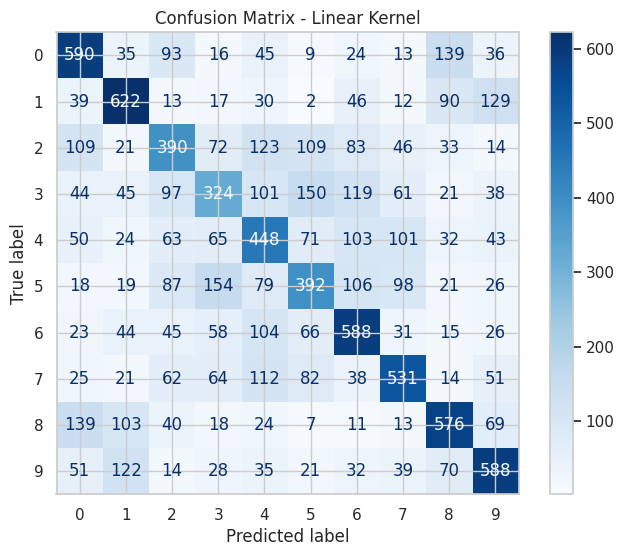

Training and Evaluating Kernels:  25%|██▌       | 1/4 [17:15<51:45, 1035.26s/it]


Starting with the 'poly' kernel...
Done! Accuracy: 0.5888 | Time taken: 1117.66 sec

Classification Report for POLY Kernel:
              precision    recall  f1-score   support

           0       0.61      0.66      0.63      1000
           1       0.71      0.75      0.73      1000
           2       0.49      0.52      0.50      1000
           3       0.38      0.39      0.38      1000
           4       0.52      0.55      0.53      1000
           5       0.47      0.44      0.45      1000
           6       0.66      0.66      0.66      1000
           7       0.68      0.61      0.65      1000
           8       0.68      0.64      0.66      1000
           9       0.71      0.68      0.70      1000

    accuracy                           0.59     10000
   macro avg       0.59      0.59      0.59     10000
weighted avg       0.59      0.59      0.59     10000



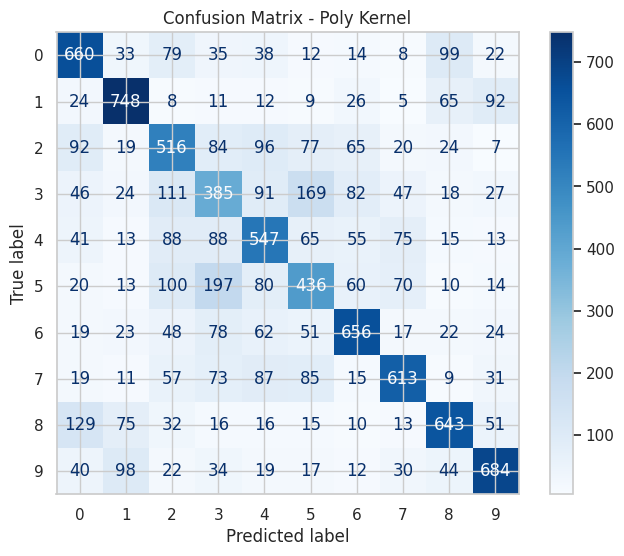

Training and Evaluating Kernels:  50%|█████     | 2/4 [37:59<38:35, 1157.97s/it]


Starting with the 'rbf' kernel...
Done! Accuracy: 0.6055 | Time taken: 932.28 sec

Classification Report for RBF Kernel:
              precision    recall  f1-score   support

           0       0.64      0.68      0.66      1000
           1       0.71      0.74      0.73      1000
           2       0.56      0.49      0.52      1000
           3       0.44      0.41      0.42      1000
           4       0.53      0.57      0.55      1000
           5       0.49      0.48      0.49      1000
           6       0.64      0.69      0.67      1000
           7       0.68      0.64      0.66      1000
           8       0.68      0.67      0.67      1000
           9       0.66      0.69      0.67      1000

    accuracy                           0.61     10000
   macro avg       0.60      0.61      0.60     10000
weighted avg       0.60      0.61      0.60     10000



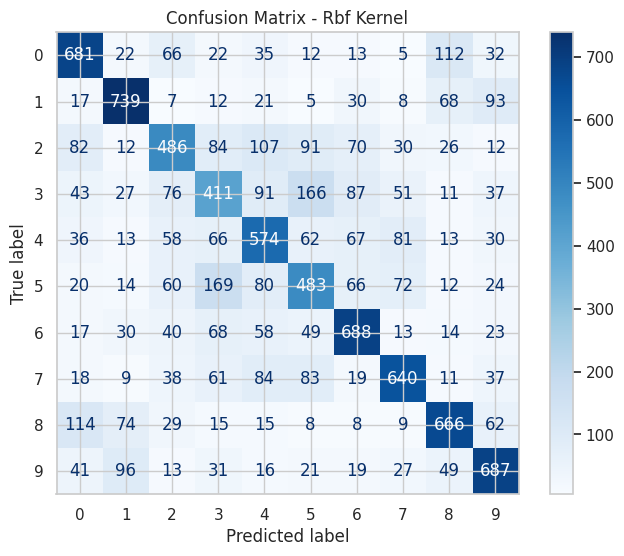

Training and Evaluating Kernels:  75%|███████▌  | 3/4 [57:11<19:15, 1155.63s/it]


Starting with the 'sigmoid' kernel...
Done! Accuracy: 0.1593 | Time taken: 1258.39 sec

Classification Report for SIGMOID Kernel:
              precision    recall  f1-score   support

           0       0.11      0.41      0.17      1000
           1       0.42      0.17      0.25      1000
           2       0.12      0.19      0.14      1000
           3       0.27      0.07      0.10      1000
           4       0.20      0.02      0.03      1000
           5       0.40      0.12      0.19      1000
           6       0.20      0.12      0.15      1000
           7       0.20      0.10      0.14      1000
           8       0.47      0.14      0.22      1000
           9       0.12      0.25      0.16      1000

    accuracy                           0.16     10000
   macro avg       0.25      0.16      0.16     10000
weighted avg       0.25      0.16      0.16     10000



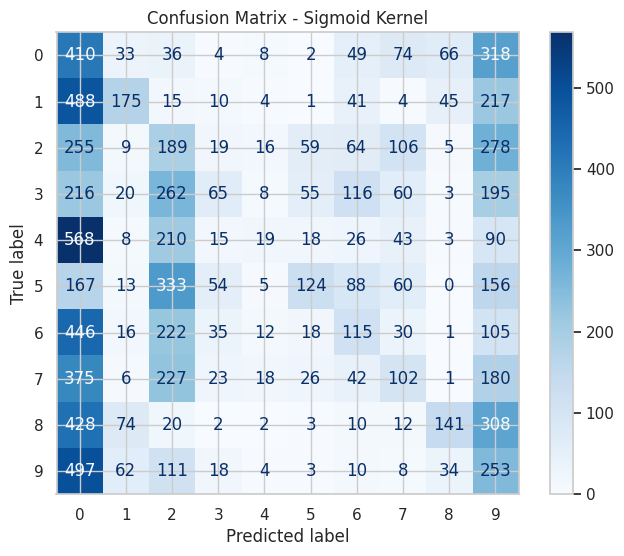

Training and Evaluating Kernels: 100%|██████████| 4/4 [1:20:53<00:00, 1213.50s/it]


In [ ]:
# looping through each kernel to train and evaluate
from sklearn.metrics import classification_report
for kernel in tqdm(kernels, desc="Training and Evaluating Kernels"):
    print(f"\nStarting with the '{kernel}' kernel...")

    start_time = time.time()

    # train the SVM model
    clf = SVC(kernel=kernel)
    clf.fit(X_train, y_train)

    elapsed = time.time() - start_time
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # print out results for the kernel
    print(f"Done! Accuracy: {acc:.4f} | Time taken: {elapsed:.2f} sec")

    # save the model and prediction
    models[kernel] = clf
    predictions[kernel] = y_pred
    accuracies.append(acc)
    times.append(elapsed)

    # save model to disk
    with open(f'svm_{kernel}.pkl', 'wb') as f:
        pickle.dump(clf, f)

    # print classification report and confusion matrix
    print(f"\nClassification Report for {kernel.upper()} Kernel:")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
    plt.title(f"Confusion Matrix - {kernel.capitalize()} Kernel")
    plt.show()


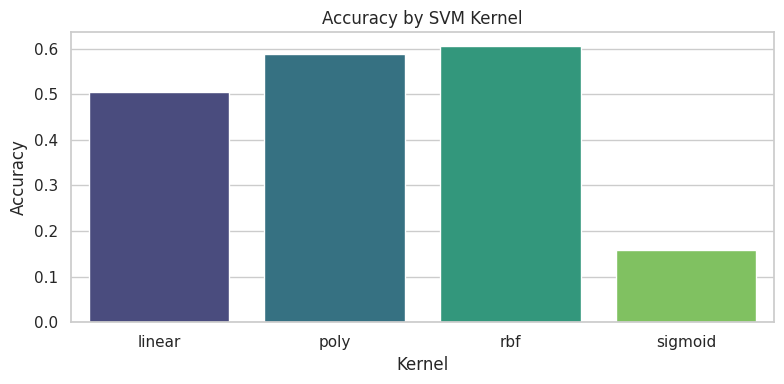

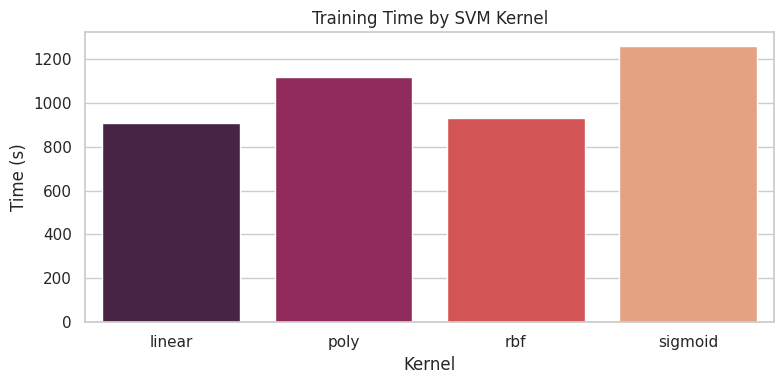

In [ ]:
# plot comparison of accuracies
plt.figure(figsize=(8, 4))
sns.barplot(x=kernels, y=accuracies, palette='viridis')
plt.title("Accuracy by SVM Kernel")
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# plot comparison of training times
plt.figure(figsize=(8, 4))
sns.barplot(x=kernels, y=times, palette='rocket')
plt.title("Training Time by SVM Kernel")
plt.xlabel("Kernel")
plt.ylabel("Time (s)")
plt.tight_layout()
plt.show()


In [ ]:
# determine and print best kernel based on accuracy
best_idx = np.argmax(accuracies)
best_kernel = kernels[best_idx]
best_acc = accuracies[best_idx]

print(f"\n🏆 The best kernel is: '{best_kernel}' with Accuracy = {best_acc:.4f}")



🏆 The best kernel is: 'rbf' with Accuracy = 0.6055
